# Exploratory Data Analysis: Crypto Volatility Detection

This notebook explores the feature data to:
1. Understand the distribution of future volatility
2. Identify volatility spikes using percentile analysis
3. Set the threshold (τ) for binary classification
4. Analyze feature distributions and correlations


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [3]:
# Load features
features_path = Path('../data/processed/features.parquet')
df = pd.read_parquet(features_path)

print(f"Loaded {len(df)} feature rows")
print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns: {list(df.columns)}")
df.head()


Loaded 3469 feature rows
Time range: 2025-11-12 17:35:01.708523+00:00 to 2025-11-12 17:52:09.463143+00:00

Columns: ['timestamp', 'product_id', 'midprice', 'midprice_returns', 'bid_ask_spread', 'trade_intensity', 'order_book_imbalance', 'rolling_std_returns', 'rolling_mean_spread', 'rolling_mean_imbalance', 'future_volatility']


,timestamp,product_id,midprice,midprice_returns,bid_ask_spread,trade_intensity,order_book_imbalance,rolling_std_returns,rolling_mean_spread,rolling_mean_imbalance,future_volatility
0,2025-11-12 17:35:01.708523+00:00,BTC-USD,101673.985,0.0,9.835358e-08,0.050000,-0.487776,0.0,9.835358e-08,-0.546731,NaN
1,2025-11-12 17:35:01.957796+00:00,BTC-USD,101673.985,0.0,9.835358e-08,0.066667,-0.462348,0.0,9.835358e-08,-0.525636,0.000000
2,2025-11-12 17:35:02.458836+00:00,BTC-USD,101673.985,0.0,9.835358e-08,0.083333,-0.508983,0.0,9.835358e-08,-0.522305,0.000000
3,2025-11-12 17:35:02.708122+00:00,BTC-USD,101673.985,0.0,9.835358e-08,0.100000,-0.515991,0.0,9.835358e-08,-0.521253,0.000000
4,2025-11-12 17:35:02.853448+00:00,BTC-USD,101673.985,0.0,9.835358e-08,0.116667,-0.515991,0.0,9.835358e-08,-0.520501,0.000001


## 1. Future Volatility Distribution Analysis


In [4]:
# Basic statistics
vol_stats = df['future_volatility'].describe()
print("Future Volatility Statistics:")
print(vol_stats)
print(f"\nNon-zero values: {(df['future_volatility'] > 0).sum()} / {len(df)}")
print(f"Zero values: {(df['future_volatility'] == 0).sum()} / {len(df)}")


Future Volatility Statistics:
count    3467.000000
mean        0.000028
std         0.000006
min         0.000000
25%         0.000025
50%         0.000028
75%         0.000031
max         0.000049
Name: future_volatility, dtype: float64

Non-zero values: 3464 / 3469
Zero values: 3 / 3469


In [5]:
# Percentile analysis for threshold selection
percentiles = [50, 75, 90, 95, 97.5, 99, 99.5, 99.9]
percentile_values = {p: df['future_volatility'].quantile(p/100) for p in percentiles}

print("Percentile Analysis:")
print("=" * 50)
for p, val in percentile_values.items():
    count = (df['future_volatility'] >= val).sum()
    pct = (count / len(df)) * 100
    print(f"{p:5.1f}th percentile: {val:.8f}  ({count:5d} samples, {pct:5.2f}%)")

# Select threshold (τ) - using 95th percentile
tau = percentile_values[95]
print(f"\nSelected threshold (τ): {tau:.8f} (95th percentile)")

# Create binary labels
df['volatility_spike'] = (df['future_volatility'] >= tau).astype(int)
print(f"\nLabel Distribution:")
print(f"  Volatility Spike (1): {(df['volatility_spike'] == 1).sum()} ({100*(df['volatility_spike'] == 1).sum()/len(df):.2f}%)")
print(f"  Normal (0): {(df['volatility_spike'] == 0).sum()} ({100*(df['volatility_spike'] == 0).sum()/len(df):.2f}%)")


Percentile Analysis:
 50.0th percentile: 0.00002802  ( 1735 samples, 50.01%)
 75.0th percentile: 0.00003074  (  867 samples, 24.99%)
 90.0th percentile: 0.00003452  (  347 samples, 10.00%)
 95.0th percentile: 0.00003615  (  174 samples,  5.02%)
 97.5th percentile: 0.00004099  (   87 samples,  2.51%)
 99.0th percentile: 0.00004545  (   35 samples,  1.01%)
 99.5th percentile: 0.00004669  (   18 samples,  0.52%)
 99.9th percentile: 0.00004820  (    4 samples,  0.12%)

Selected threshold (τ): 0.00003615 (95th percentile)

Label Distribution:
  Volatility Spike (1): 174 (5.02%)
  Normal (0): 3295 (94.98%)


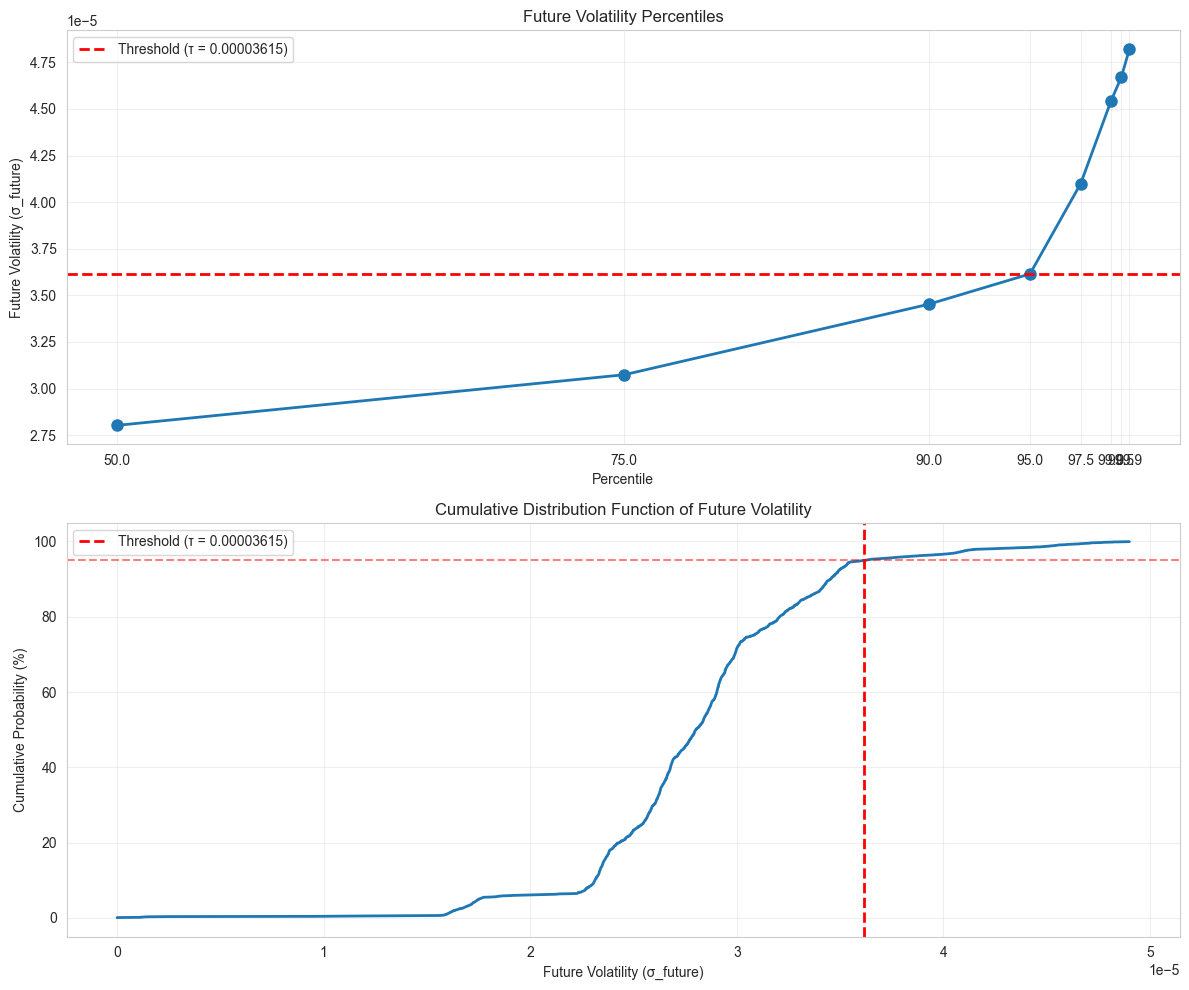

In [6]:
# Percentile plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Percentile values
percentiles_list = list(percentile_values.keys())
values_list = list(percentile_values.values())

axes[0].plot(percentiles_list, values_list, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Percentile')
axes[0].set_ylabel('Future Volatility (σ_future)')
axes[0].set_title('Future Volatility Percentiles')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(percentiles_list)

# Add threshold line
axes[0].axhline(tau, color='red', linestyle='--', linewidth=2, label=f'Threshold (τ = {tau:.8f})')
axes[0].legend()

# Plot 2: CDF
sorted_vol = np.sort(df['future_volatility'])
cdf = np.arange(1, len(sorted_vol) + 1) / len(sorted_vol)
axes[1].plot(sorted_vol, cdf * 100, linewidth=2)
axes[1].axvline(tau, color='red', linestyle='--', linewidth=2, label=f'Threshold (τ = {tau:.8f})')
axes[1].axhline(95, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Future Volatility (σ_future)')
axes[1].set_ylabel('Cumulative Probability (%)')
axes[1].set_title('Cumulative Distribution Function of Future Volatility')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/volatility_percentiles.png', dpi=150, bbox_inches='tight')
plt.show()


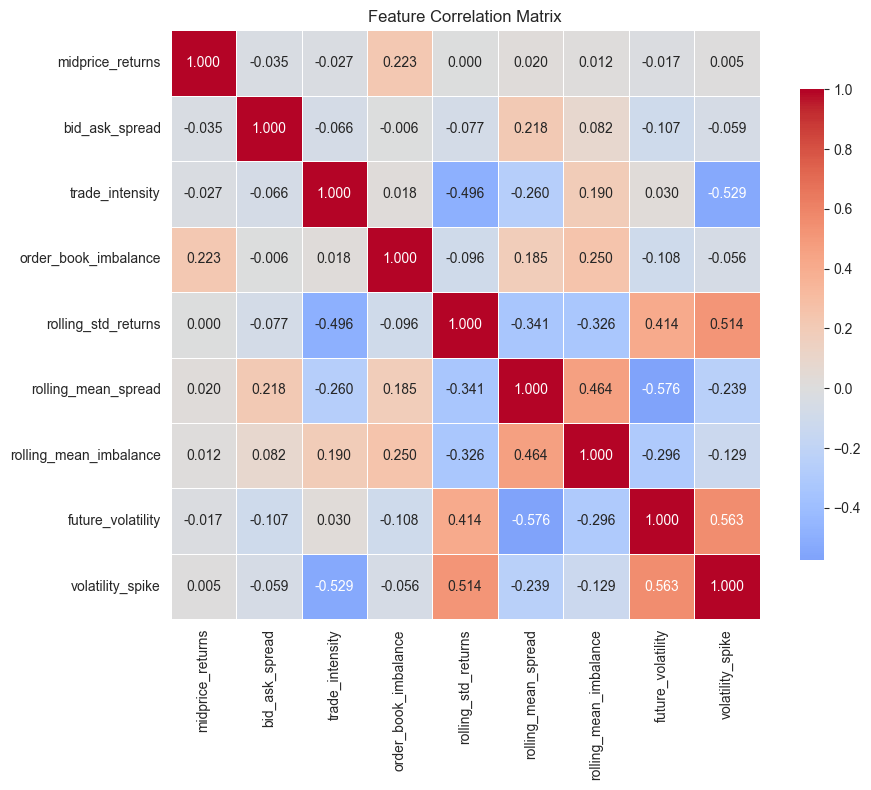

In [7]:
# Feature correlation
feature_cols = ['midprice_returns', 'bid_ask_spread', 'trade_intensity', 
                'order_book_imbalance', 'rolling_std_returns', 
                'rolling_mean_spread', 'rolling_mean_imbalance']

corr_cols = feature_cols + ['future_volatility', 'volatility_spike']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../reports/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
print("=" * 80)
print("EDA SUMMARY")
print("=" * 80)
print(f"\nDataset: {len(df)} samples")
print(f"Selected Threshold (τ): {tau:.8f} (95th percentile)")
print(f"Volatility Spikes: {(df['volatility_spike'] == 1).sum()} ({(df['volatility_spike'] == 1).sum()/len(df)*100:.2f}%)")
print(f"\nJustification: 95th percentile captures top 5% of volatility events, providing")
print("sufficient positive examples while balancing sensitivity and specificity.")


EDA SUMMARY

Dataset: 3469 samples
Selected Threshold (τ): 0.00003615 (95th percentile)
Volatility Spikes: 174 (5.02%)

Justification: 95th percentile captures top 5% of volatility events, providing
sufficient positive examples while balancing sensitivity and specificity.
